# Distance Metrics — Illustrated

Many algorithms (KNN, K-Means, hierarchical clustering, DBSCAN, t-SNE, …) are
**parameterised by a distance function**. The choice of metric quietly changes
what "similar" means.

| Metric | Formula | When |
|---|---|---|
| Euclidean | $\sqrt{\sum_i (x_i - y_i)^2}$ | continuous, isotropic features |
| Manhattan | $\sum_i \lvert x_i - y_i\rvert$ | grid / city-block / robust to outliers |
| Chebyshev | $\max_i \lvert x_i - y_i\rvert$ | bounding-box similarity |
| Cosine | $1 - \dfrac{x\cdot y}{\lVert x\rVert\,\lVert y\rVert}$ | text, embeddings, magnitude is irrelevant |
| Mahalanobis | $\sqrt{(x-y)^\top \Sigma^{-1}(x-y)}$ | correlated features |
| Hamming | $\sum_i \mathbb{1}[x_i \neq y_i]$ | binary / categorical |


## The picture — different metrics produce different unit balls

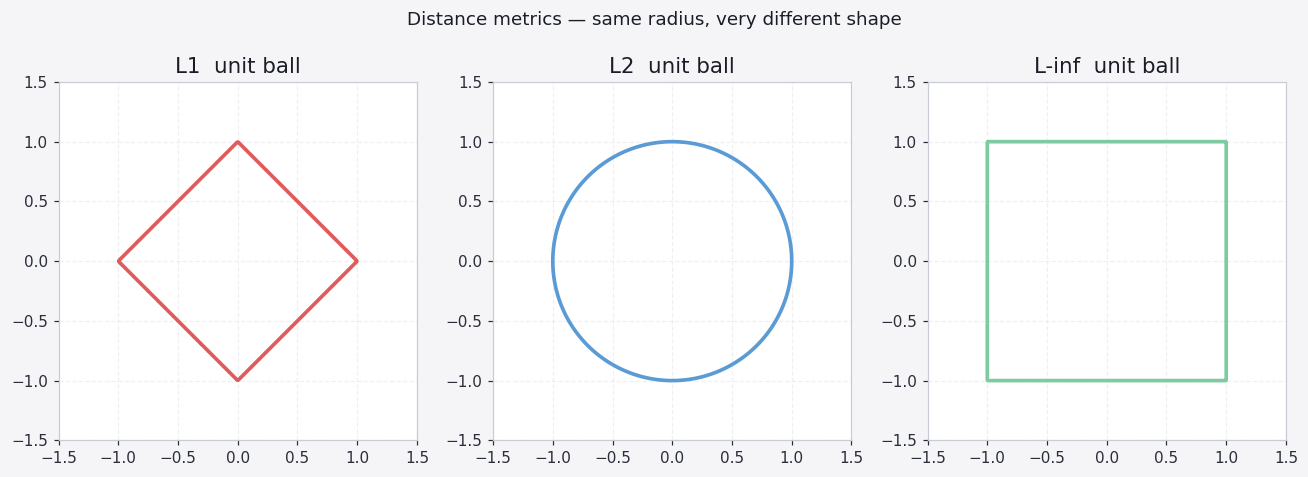

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 400), np.linspace(-1.5, 1.5, 400))
metrics = [('L1', np.abs(xx)+np.abs(yy)),
           ('L2', np.sqrt(xx*xx+yy*yy)),
           ('L-inf', np.maximum(np.abs(xx), np.abs(yy)))]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (n, D), c in zip(axes, metrics, [P[1], P[0], P[3]]):
    ax.contour(xx, yy, D, levels=[1.0], colors=[c], linewidths=2.4)
    ax.set_title(f'{n}  unit ball'); ax.set_aspect('equal')
    ax.set_xlim(-1.5,1.5); ax.set_ylim(-1.5,1.5); ax.grid(True)
fig.suptitle('Distance metrics — same radius, very different shape', y=1.03)
plt.tight_layout(); plt.show()


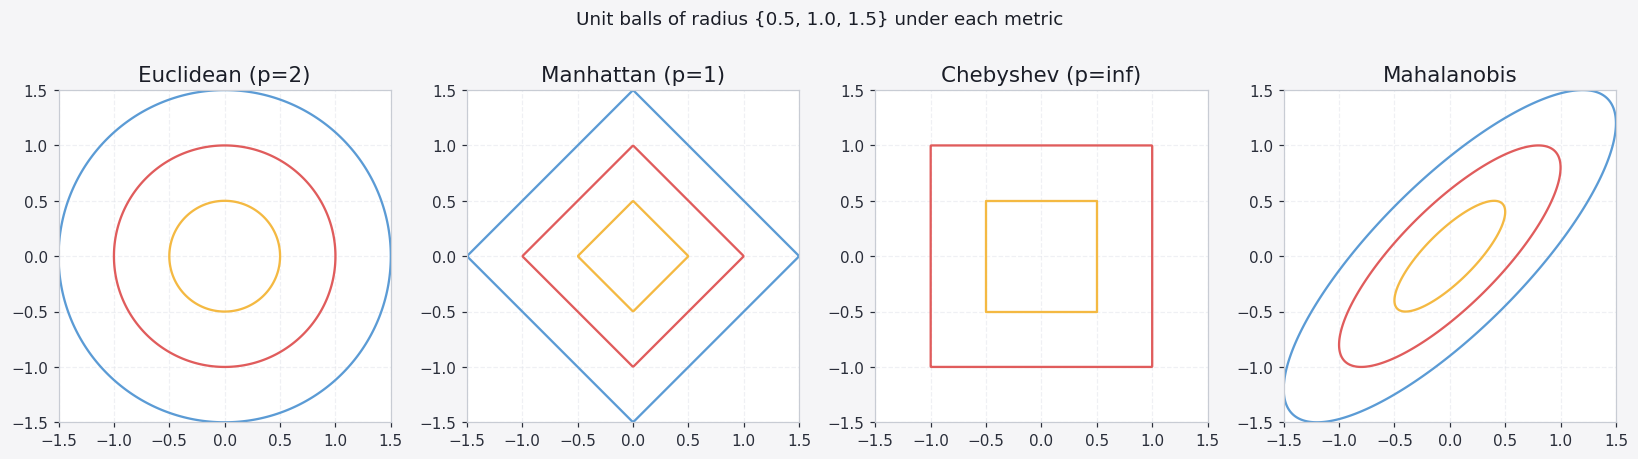

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':110,
}
plt.rcParams.update(PLT_STYLE)
PALETTE = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']

from scipy.spatial.distance import cdist
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_blobs

# Unit ball under each metric, in 2-D
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 400), np.linspace(-1.5, 1.5, 400))
pts    = np.column_stack([xx.ravel(), yy.ravel()])
ref    = np.array([[0, 0]])

cov = np.array([[1.0, 0.8],[0.8, 1.0]])
inv = np.linalg.inv(cov)

def maha(p, ref, inv):
    d = p - ref
    return np.sqrt(np.einsum('ni,ij,nj->n', d, inv, d))

balls = {
    'Euclidean (p=2)':   cdist(pts, ref, 'euclidean').ravel(),
    'Manhattan (p=1)':   cdist(pts, ref, 'cityblock').ravel(),
    'Chebyshev (p=inf)': cdist(pts, ref, 'chebyshev').ravel(),
    'Mahalanobis':       maha(pts, ref, inv),
}

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, (name, d) in zip(axes, balls.items()):
    Z = d.reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=[0.5, 1.0, 1.5], colors=[PALETTE[2], PALETTE[1], PALETTE[0]])
    ax.set_title(name); ax.set_aspect('equal'); ax.grid(True)
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
fig.suptitle('Unit balls of radius {0.5, 1.0, 1.5} under each metric', y=1.02)
plt.tight_layout(); plt.show()


---
## Effect on a KNN decision boundary

Same data, same K, three metrics.


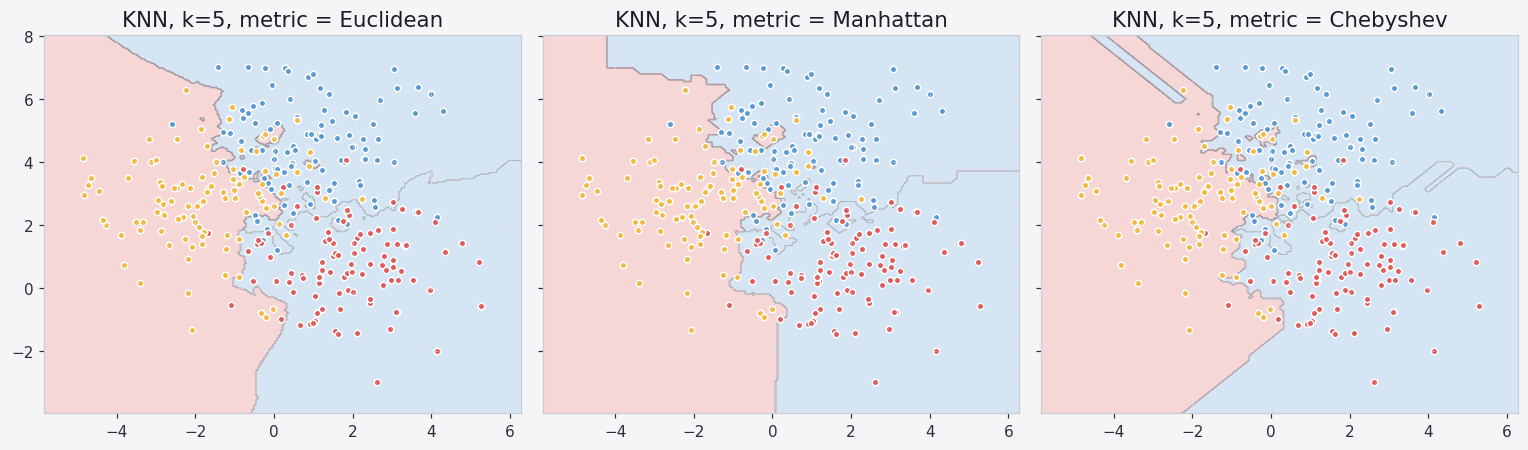

In [3]:
X, y = make_blobs(n_samples=300, centers=3, cluster_std=1.4, random_state=0)
gx, gy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 250),
                     np.linspace(X[:,1].min()-1, X[:,1].max()+1, 250))
grid = np.column_stack([gx.ravel(), gy.ravel()])

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
for ax, metric, label in zip(axes,
                             ['euclidean', 'manhattan', 'chebyshev'],
                             ['Euclidean', 'Manhattan', 'Chebyshev']):
    knn = KNeighborsClassifier(n_neighbors=5, metric=metric).fit(X, y)
    Z = knn.predict(grid).reshape(gx.shape)
    ax.contourf(gx, gy, Z, alpha=0.25,
                colors=[PALETTE[0], PALETTE[1], PALETTE[3]])
    for c in range(3):
        ax.scatter(X[y==c, 0], X[y==c, 1], s=18,
                   color=PALETTE[c], edgecolor='white')
    ax.set_title(f'KNN, k=5, metric = {label}')
    ax.grid(True)
plt.tight_layout(); plt.show()


---
## Cosine vs Euclidean — when magnitude lies

Three "documents" with similar topic mix but very different word counts.
Euclidean treats long docs as far away; cosine ignores length.


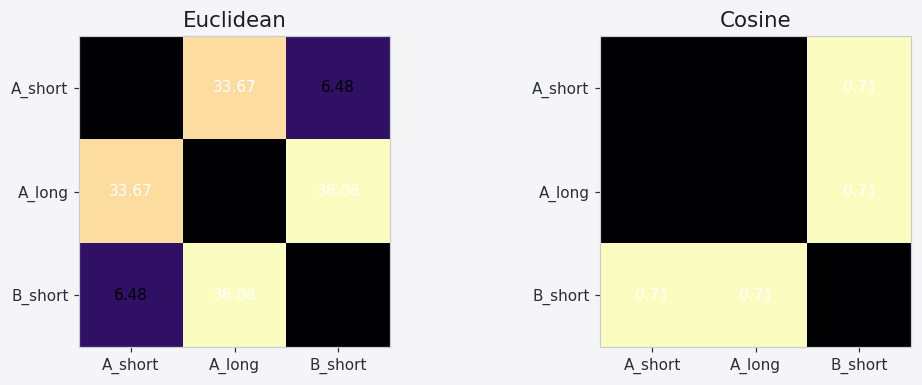

Notice: A_long is FAR from A_short in Euclidean (different counts) but CLOSE in cosine (same topic).


In [4]:
docs = np.array([
    [3, 1, 0, 2],     # short doc, topic A
    [30, 10, 0, 20],  # long doc,  topic A   (same proportions as #1)
    [1, 4, 5, 0],     # short doc, topic B
])
labels = ['A_short', 'A_long', 'B_short']
euc = cdist(docs, docs, 'euclidean')
cos = cdist(docs, docs, 'cosine')

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, m, title in zip(axes, [euc, cos], ['Euclidean', 'Cosine']):
    im = ax.imshow(m, cmap='magma')
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(labels); ax.set_yticklabels(labels)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{m[i,j]:.2f}', ha='center', va='center',
                    color='white' if m[i,j] > m.max()/2 else 'black', fontsize=10)
    ax.set_title(title)
plt.tight_layout(); plt.show()
print('Notice: A_long is FAR from A_short in Euclidean (different counts) but CLOSE in cosine (same topic).')


---
## Why scaling matters for distance-based models

Without scaling, the largest-magnitude feature dominates every distance.


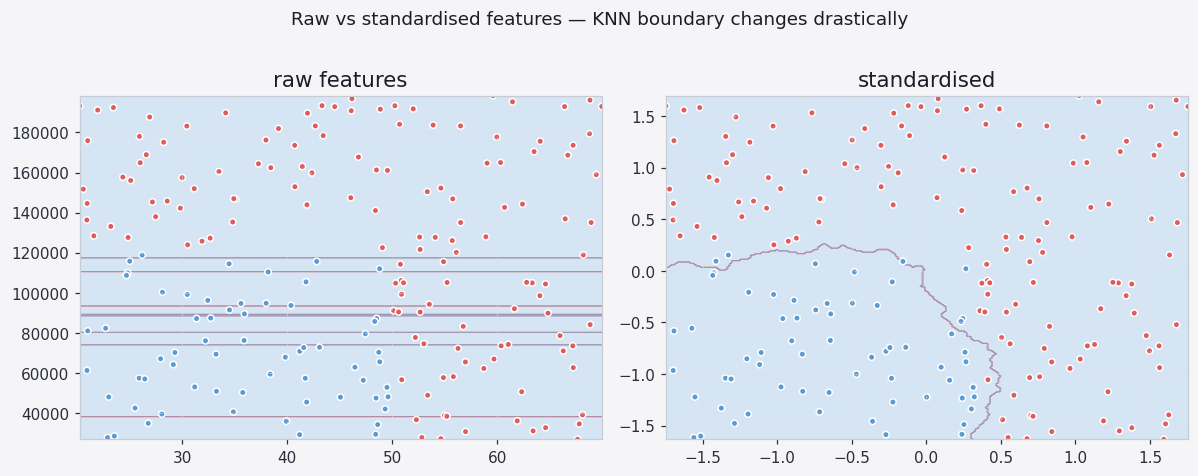

In [5]:
from sklearn.preprocessing import StandardScaler

rng = np.random.RandomState(0)
n = 200
age    = rng.uniform(20, 70, n)
salary = rng.uniform(25_000, 200_000, n)        # 1000x larger scale
class_ = ((age > 50) | (salary > 120_000)).astype(int)

X_raw    = np.column_stack([age, salary])
X_scaled = StandardScaler().fit_transform(X_raw)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, X, title in zip(axes, [X_raw, X_scaled], ['raw features', 'standardised']):
    knn = KNeighborsClassifier(n_neighbors=15).fit(X, class_)
    h = 0.05 if title == 'standardised' else None
    gx, gy = np.meshgrid(np.linspace(X[:,0].min(), X[:,0].max(), 250),
                         np.linspace(X[:,1].min(), X[:,1].max(), 250))
    Z = knn.predict(np.column_stack([gx.ravel(), gy.ravel()])).reshape(gx.shape)
    ax.contourf(gx, gy, Z, alpha=0.25, colors=[PALETTE[0], PALETTE[1]])
    ax.scatter(X[:,0], X[:,1], c=[PALETTE[0] if c==0 else PALETTE[1] for c in class_],
               s=18, edgecolor='white')
    ax.set_title(title); ax.grid(True)
fig.suptitle('Raw vs standardised features — KNN boundary changes drastically', y=1.02)
plt.tight_layout(); plt.show()


---
## When to use what

- **Euclidean** — default for continuous, isotropic, similarly-scaled features. *Always scale first.*
- **Manhattan** — robust when individual features may contain outliers; on a grid (e.g. board games).
- **Cosine** — text/TF-IDF, embeddings, recommender systems where direction encodes meaning.
- **Mahalanobis** — strongly correlated features; one-class anomaly detection.
- **Hamming** — categorical / binary one-hot features.

> Rule: **standardise** continuous features before any distance-based model. Then think about whether magnitude or direction is what you really mean by "similar".
